# Базовая модель прогнозирования(ETNA)

Сегодня мы попробуем построить наш первый пайплайн прогнозированяи временных рядов при помощи библиотеки [ETNA](https://github.com/etna-team/etna). 

Любые вопросы по семинару, библиотеке и временным рядам в целом можно(нужно) задавать в нашей [группе в tg](https://t.me/etna_support)


### План семинара 
1. TSDataset - как загрузить данные
2. Pipeline - как создать модель прогнозирования
3. Кросcвалидация - как оценить качество пайплайна


In [2]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")

# 1. TSDataset -- базовая структура данных
`TSDataset` - основной контейнер, с которым работают другие объекты библиотеки
* проводит валидацию данных
* взаимодействует с другими частями пайплайна прогнозирования
* помогает проводить базовую аналитику данных
* генерирует будущие значения ряда для прогнозирования
* удобно индексироваться по рядам
  * первый индекс отвечает за временное измерение
  * второй - за сегмент
  * третий - за отдельный столбец


In [3]:
from etna.datasets import TSDataset

## 1.1 Создание датасета

В библиотеке существует 2 стандартных формата данных. Чаще всего данные представлены в **long** формате, в нем датафрэйм должен содержать следующий набор колонок:
1. **timestamp** - колонка с временной отметкой
2. **segment** - колонка с названием временного ряда, которому принадлежит измерение
3. **target** - значение измерения

In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_1/data/nordic_merch_sales.csv")
df.head()

,timestamp,target,segment
0,2015-01-01,329,Finland_KaggleMart_Kaggle Mug
1,2015-01-01,520,Finland_KaggleMart_Kaggle Hat
2,2015-01-01,146,Finland_KaggleMart_Kaggle Sticker
3,2015-01-01,572,Finland_KaggleRama_Kaggle Mug
4,2015-01-01,911,Finland_KaggleRama_Kaggle Hat


Данные в таком формате подаются в конструктор

In [7]:
ts = TSDataset(df=df, freq="D")  # Передаем данные в long формате + частотность
ts.head()

segment,Finland_KaggleMart_Kaggle Hat,Finland_KaggleMart_Kaggle Mug,Finland_KaggleMart_Kaggle Sticker,Finland_KaggleRama_Kaggle Hat,Finland_KaggleRama_Kaggle Mug,Finland_KaggleRama_Kaggle Sticker,Norway_KaggleMart_Kaggle Hat,Norway_KaggleMart_Kaggle Mug,Norway_KaggleMart_Kaggle Sticker,Norway_KaggleRama_Kaggle Hat,Norway_KaggleRama_Kaggle Mug,Norway_KaggleRama_Kaggle Sticker,Sweden_KaggleMart_Kaggle Hat,Sweden_KaggleMart_Kaggle Mug,Sweden_KaggleMart_Kaggle Sticker,Sweden_KaggleRama_Kaggle Hat,Sweden_KaggleRama_Kaggle Mug,Sweden_KaggleRama_Kaggle Sticker
feature,target,target,target,target,target,target,target,target,target,target,target,target,target,target,target,target,target,target
timestamp,,,,,,,,,,,,,,,,,,
2015-01-01,520.0,329.0,146.0,911.0,572.0,283.0,906.0,526.0,250.0,1461.0,1005.0,395.0,624.0,440.0,175.0,1195.0,706.0,324.0
2015-01-02,493.0,318.0,127.0,794.0,544.0,249.0,845.0,538.0,237.0,1446.0,949.0,415.0,572.0,384.0,155.0,986.0,653.0,293.0
2015-01-03,535.0,360.0,141.0,843.0,579.0,265.0,930.0,614.0,254.0,1631.0,1029.0,451.0,630.0,420.0,173.0,1167.0,734.0,319.0
2015-01-04,544.0,332.0,125.0,873.0,582.0,245.0,889.0,589.0,255.0,1540.0,957.0,455.0,697.0,406.0,169.0,1112.0,657.0,300.0
2015-01-05,378.0,243.0,102.0,668.0,423.0,187.0,671.0,435.0,184.0,1126.0,739.0,310.0,442.0,298.0,127.0,796.0,512.0,227.0


In [8]:
ts[:"2015-06-01", "Finland_KaggleMart_Kaggle Hat", :]

segment,Finland_KaggleMart_Kaggle Hat
feature,target
timestamp,
2015-01-01,520.0
2015-01-02,493.0
2015-01-03,535.0
2015-01-04,544.0
2015-01-05,378.0
...,...
2015-05-28,361.0
2015-05-29,385.0


Внутри себя `TSDataset` преобразует данные в **wide** формат - это датафрэйм с мультииндексом (timestamp, segment, column). 

Можно сделать это и руками

In [9]:
df_wide = TSDataset.to_dataset(df)
df_wide.head()

segment,Finland_KaggleMart_Kaggle Hat,Finland_KaggleMart_Kaggle Mug,Finland_KaggleMart_Kaggle Sticker,Finland_KaggleRama_Kaggle Hat,Finland_KaggleRama_Kaggle Mug,Finland_KaggleRama_Kaggle Sticker,Norway_KaggleMart_Kaggle Hat,Norway_KaggleMart_Kaggle Mug,Norway_KaggleMart_Kaggle Sticker,Norway_KaggleRama_Kaggle Hat,Norway_KaggleRama_Kaggle Mug,Norway_KaggleRama_Kaggle Sticker,Sweden_KaggleMart_Kaggle Hat,Sweden_KaggleMart_Kaggle Mug,Sweden_KaggleMart_Kaggle Sticker,Sweden_KaggleRama_Kaggle Hat,Sweden_KaggleRama_Kaggle Mug,Sweden_KaggleRama_Kaggle Sticker
feature,target,target,target,target,target,target,target,target,target,target,target,target,target,target,target,target,target,target
timestamp,,,,,,,,,,,,,,,,,,
2015-01-01,520.0,329.0,146.0,911.0,572.0,283.0,906.0,526.0,250.0,1461.0,1005.0,395.0,624.0,440.0,175.0,1195.0,706.0,324.0
2015-01-02,493.0,318.0,127.0,794.0,544.0,249.0,845.0,538.0,237.0,1446.0,949.0,415.0,572.0,384.0,155.0,986.0,653.0,293.0
2015-01-03,535.0,360.0,141.0,843.0,579.0,265.0,930.0,614.0,254.0,1631.0,1029.0,451.0,630.0,420.0,173.0,1167.0,734.0,319.0
2015-01-04,544.0,332.0,125.0,873.0,582.0,245.0,889.0,589.0,255.0,1540.0,957.0,455.0,697.0,406.0,169.0,1112.0,657.0,300.0
2015-01-05,378.0,243.0,102.0,668.0,423.0,187.0,671.0,435.0,184.0,1126.0,739.0,310.0,442.0,298.0,127.0,796.0,512.0,227.0


В `TSDataset` перегружен некоторый набор методов обычного датафрэйма

Например, можно отрисовать данные или посмотреть информацию по ним.

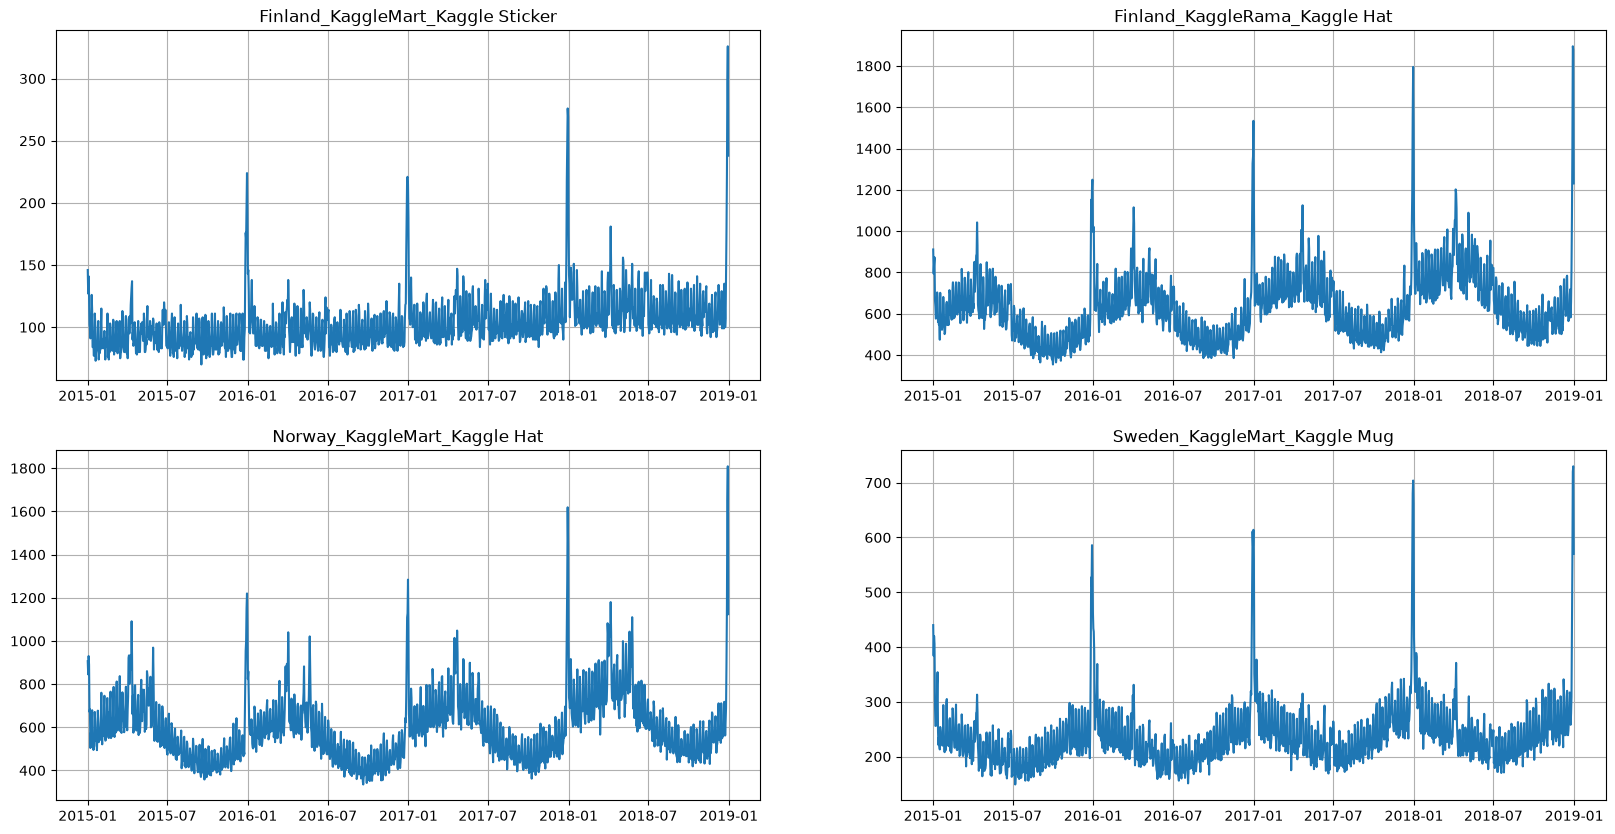

In [10]:
ts.plot(n_segments=4)

In [11]:
ts.describe().head()

,start_timestamp,end_timestamp,length,num_missing,num_segments,num_exogs,num_regressors,num_known_future,freq
segments,,,,,,,,,
Finland_KaggleMart_Kaggle Hat,2015-01-01,2018-12-31,1461,0,18,0,0,0,D
Finland_KaggleMart_Kaggle Mug,2015-01-01,2018-12-31,1461,0,18,0,0,0,D
Finland_KaggleMart_Kaggle Sticker,2015-01-01,2018-12-31,1461,0,18,0,0,0,D
Finland_KaggleRama_Kaggle Hat,2015-01-01,2018-12-31,1461,0,18,0,0,0,D
Finland_KaggleRama_Kaggle Mug,2015-01-01,2018-12-31,1461,0,18,0,0,0,D


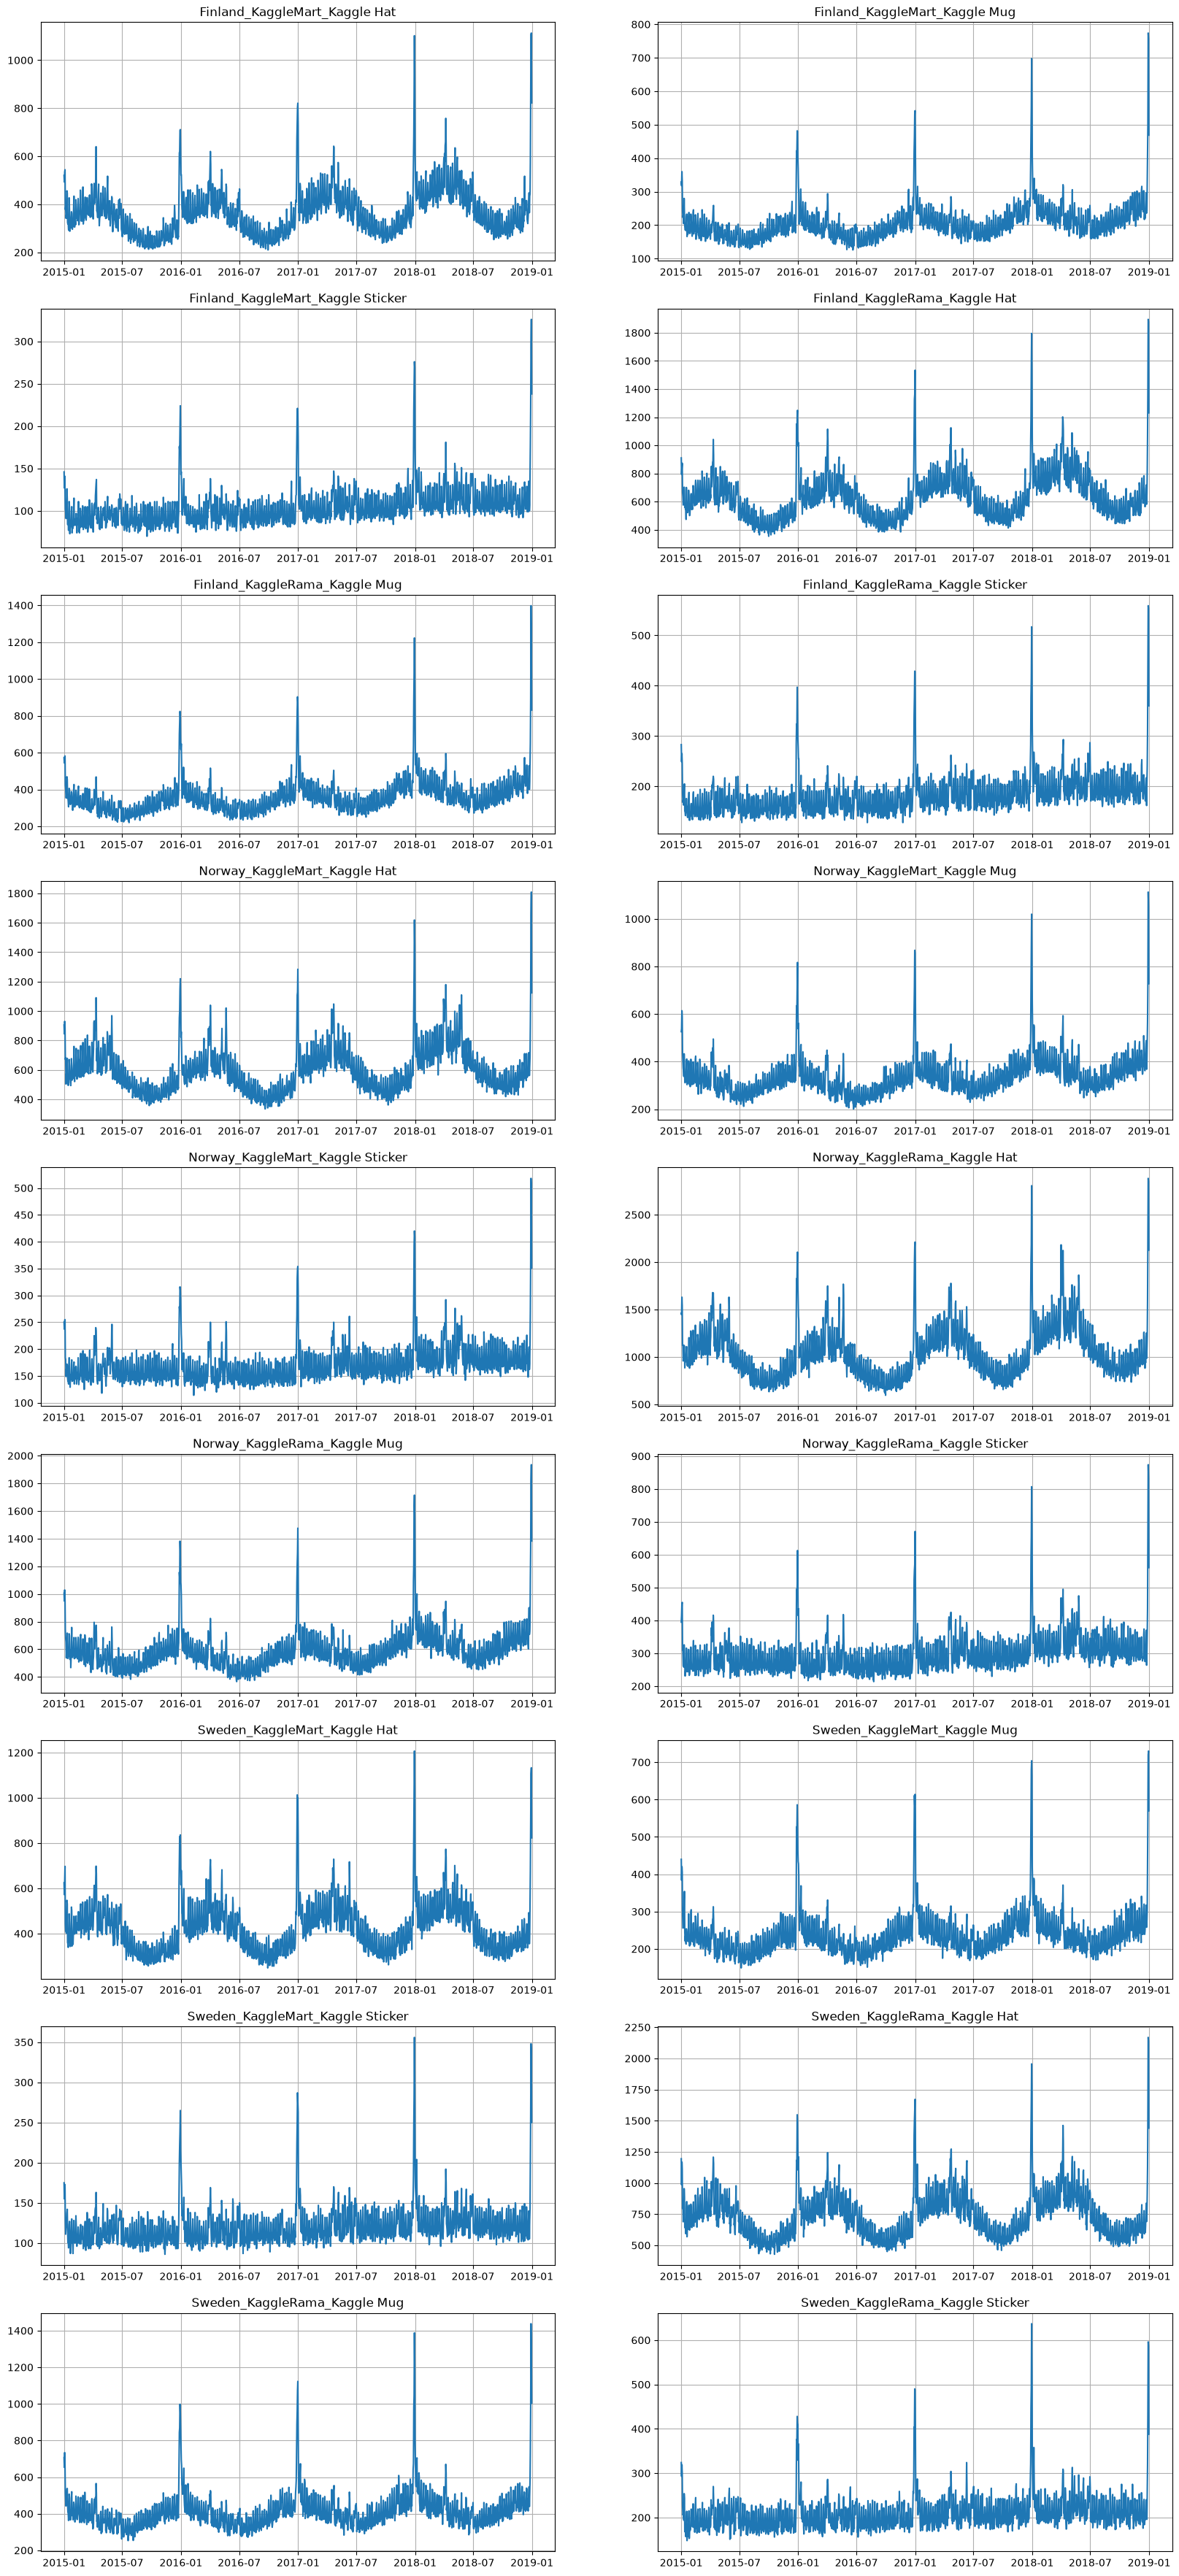

In [12]:
ts.plot(n_segments=20)

In [13]:
ts.segments

['Finland_KaggleMart_Kaggle Hat',
 'Finland_KaggleMart_Kaggle Mug',
 'Finland_KaggleMart_Kaggle Sticker',
 'Finland_KaggleRama_Kaggle Hat',
 'Finland_KaggleRama_Kaggle Mug',
 'Finland_KaggleRama_Kaggle Sticker',
 'Norway_KaggleMart_Kaggle Hat',
 'Norway_KaggleMart_Kaggle Mug',
 'Norway_KaggleMart_Kaggle Sticker',
 'Norway_KaggleRama_Kaggle Hat',
 'Norway_KaggleRama_Kaggle Mug',
 'Norway_KaggleRama_Kaggle Sticker',
 'Sweden_KaggleMart_Kaggle Hat',
 'Sweden_KaggleMart_Kaggle Mug',
 'Sweden_KaggleMart_Kaggle Sticker',
 'Sweden_KaggleRama_Kaggle Hat',
 'Sweden_KaggleRama_Kaggle Mug',
 'Sweden_KaggleRama_Kaggle Sticker']

# 2. Модели

Будем работать с семейством моделей из лекции -- SeasonalMovingAverage

In [14]:
from etna.models import (
    NaiveModel, # Полседняя известная точка  
    MovingAverageModel, # Среднее в окне
    SeasonalMovingAverageModel # Сезонное среднее в окне
)

HORIZON = 365

Загрузим данные и подготовим отложенную выборку для оценки качества

In [16]:
df = pd.read_csv("https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_1/data/nordic_merch_sales.csv")
ts = TSDataset(df=df, freq="D")

train_ts, test_ts = ts.train_test_split(  # Делаем отложенную выборку для валидации
    test_start="2018-01-01",
    test_end="2019-01-01",
)

## 2.1 Как построить прогноз

Для начала рассмотрим интерфейс модели

Обучаем модель

In [17]:
model = NaiveModel(lag=HORIZON)
model.fit(train_ts)

NaiveModel(lag = 365, )

Генерируем будущее

In [18]:
future_ts = train_ts.make_future(future_steps=HORIZON, tail_steps=model.context_size)

In [19]:
future_ts

segment,Finland_KaggleMart_Kaggle Hat,Finland_KaggleMart_Kaggle Mug,Finland_KaggleMart_Kaggle Sticker,Finland_KaggleRama_Kaggle Hat,Finland_KaggleRama_Kaggle Mug,Finland_KaggleRama_Kaggle Sticker,Norway_KaggleMart_Kaggle Hat,Norway_KaggleMart_Kaggle Mug,Norway_KaggleMart_Kaggle Sticker,Norway_KaggleRama_Kaggle Hat,Norway_KaggleRama_Kaggle Mug,Norway_KaggleRama_Kaggle Sticker,Sweden_KaggleMart_Kaggle Hat,Sweden_KaggleMart_Kaggle Mug,Sweden_KaggleMart_Kaggle Sticker,Sweden_KaggleRama_Kaggle Hat,Sweden_KaggleRama_Kaggle Mug,Sweden_KaggleRama_Kaggle Sticker
feature,target,target,target,target,target,target,target,target,target,target,target,target,target,target,target,target,target,target
timestamp,,,,,,,,,,,,,,,,,,
2017-01-01,729.0,436.0,188.0,1186.0,747.0,328.0,1072.0,688.0,308.0,1927.0,1201.0,560.0,830.0,560.0,263.0,1404.0,847.0,402.0
2017-01-02,467.0,294.0,128.0,812.0,525.0,242.0,661.0,443.0,203.0,1261.0,746.0,346.0,526.0,351.0,163.0,882.0,634.0,268.0
2017-01-03,365.0,261.0,107.0,638.0,412.0,189.0,632.0,338.0,168.0,1143.0,670.0,309.0,478.0,323.0,147.0,959.0,513.0,238.0
2017-01-04,382.0,234.0,106.0,643.0,386.0,182.0,557.0,411.0,162.0,1026.0,700.0,285.0,485.0,301.0,145.0,870.0,548.0,252.0
2017-01-05,332.0,233.0,102.0,646.0,409.0,204.0,612.0,343.0,164.0,994.0,723.0,297.0,535.0,314.0,143.0,836.0,526.0,249.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-12-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Получаем прогнозы

In [20]:
forecast_ts = model.forecast(future_ts, prediction_size=HORIZON)

In [21]:
forecast_ts

segment,Finland_KaggleMart_Kaggle Hat,Finland_KaggleMart_Kaggle Mug,Finland_KaggleMart_Kaggle Sticker,Finland_KaggleRama_Kaggle Hat,Finland_KaggleRama_Kaggle Mug,Finland_KaggleRama_Kaggle Sticker,Norway_KaggleMart_Kaggle Hat,Norway_KaggleMart_Kaggle Mug,Norway_KaggleMart_Kaggle Sticker,Norway_KaggleRama_Kaggle Hat,Norway_KaggleRama_Kaggle Mug,Norway_KaggleRama_Kaggle Sticker,Sweden_KaggleMart_Kaggle Hat,Sweden_KaggleMart_Kaggle Mug,Sweden_KaggleMart_Kaggle Sticker,Sweden_KaggleRama_Kaggle Hat,Sweden_KaggleRama_Kaggle Mug,Sweden_KaggleRama_Kaggle Sticker
feature,target,target,target,target,target,target,target,target,target,target,target,target,target,target,target,target,target,target
timestamp,,,,,,,,,,,,,,,,,,
2018-01-01,729.0,436.0,188.0,1186.0,747.0,328.0,1072.0,688.0,308.0,1927.0,1201.0,560.0,830.0,560.0,263.0,1404.0,847.0,402.0
2018-01-02,467.0,294.0,128.0,812.0,525.0,242.0,661.0,443.0,203.0,1261.0,746.0,346.0,526.0,351.0,163.0,882.0,634.0,268.0
2018-01-03,365.0,261.0,107.0,638.0,412.0,189.0,632.0,338.0,168.0,1143.0,670.0,309.0,478.0,323.0,147.0,959.0,513.0,238.0
2018-01-04,382.0,234.0,106.0,643.0,386.0,182.0,557.0,411.0,162.0,1026.0,700.0,285.0,485.0,301.0,145.0,870.0,548.0,252.0
2018-01-05,332.0,233.0,102.0,646.0,409.0,204.0,612.0,343.0,164.0,994.0,723.0,297.0,535.0,314.0,143.0,836.0,526.0,249.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-27,570.0,380.0,158.0,1024.0,638.0,282.0,836.0,530.0,244.0,1610.0,1094.0,401.0,677.0,439.0,184.0,1161.0,675.0,321.0
2018-12-28,685.0,440.0,218.0,1192.0,884.0,377.0,996.0,713.0,309.0,2019.0,1218.0,584.0,838.0,556.0,245.0,1430.0,979.0,448.0


## 2.2 Визуализируем прогноз

Видно,что прогнозы наивной модели очень похожи на реальность как по метрикам, так и по картинке

In [22]:
from etna.analysis import plot_forecast
from etna.metrics import SMAPE

In [23]:
metric = SMAPE()(y_true=test_ts, y_pred=forecast_ts)
print(f"Mean SMAPE of NaiveModel: {np.array(list(metric.values())).mean()}")

Mean SMAPE of NaiveModel: 13.166442283926543


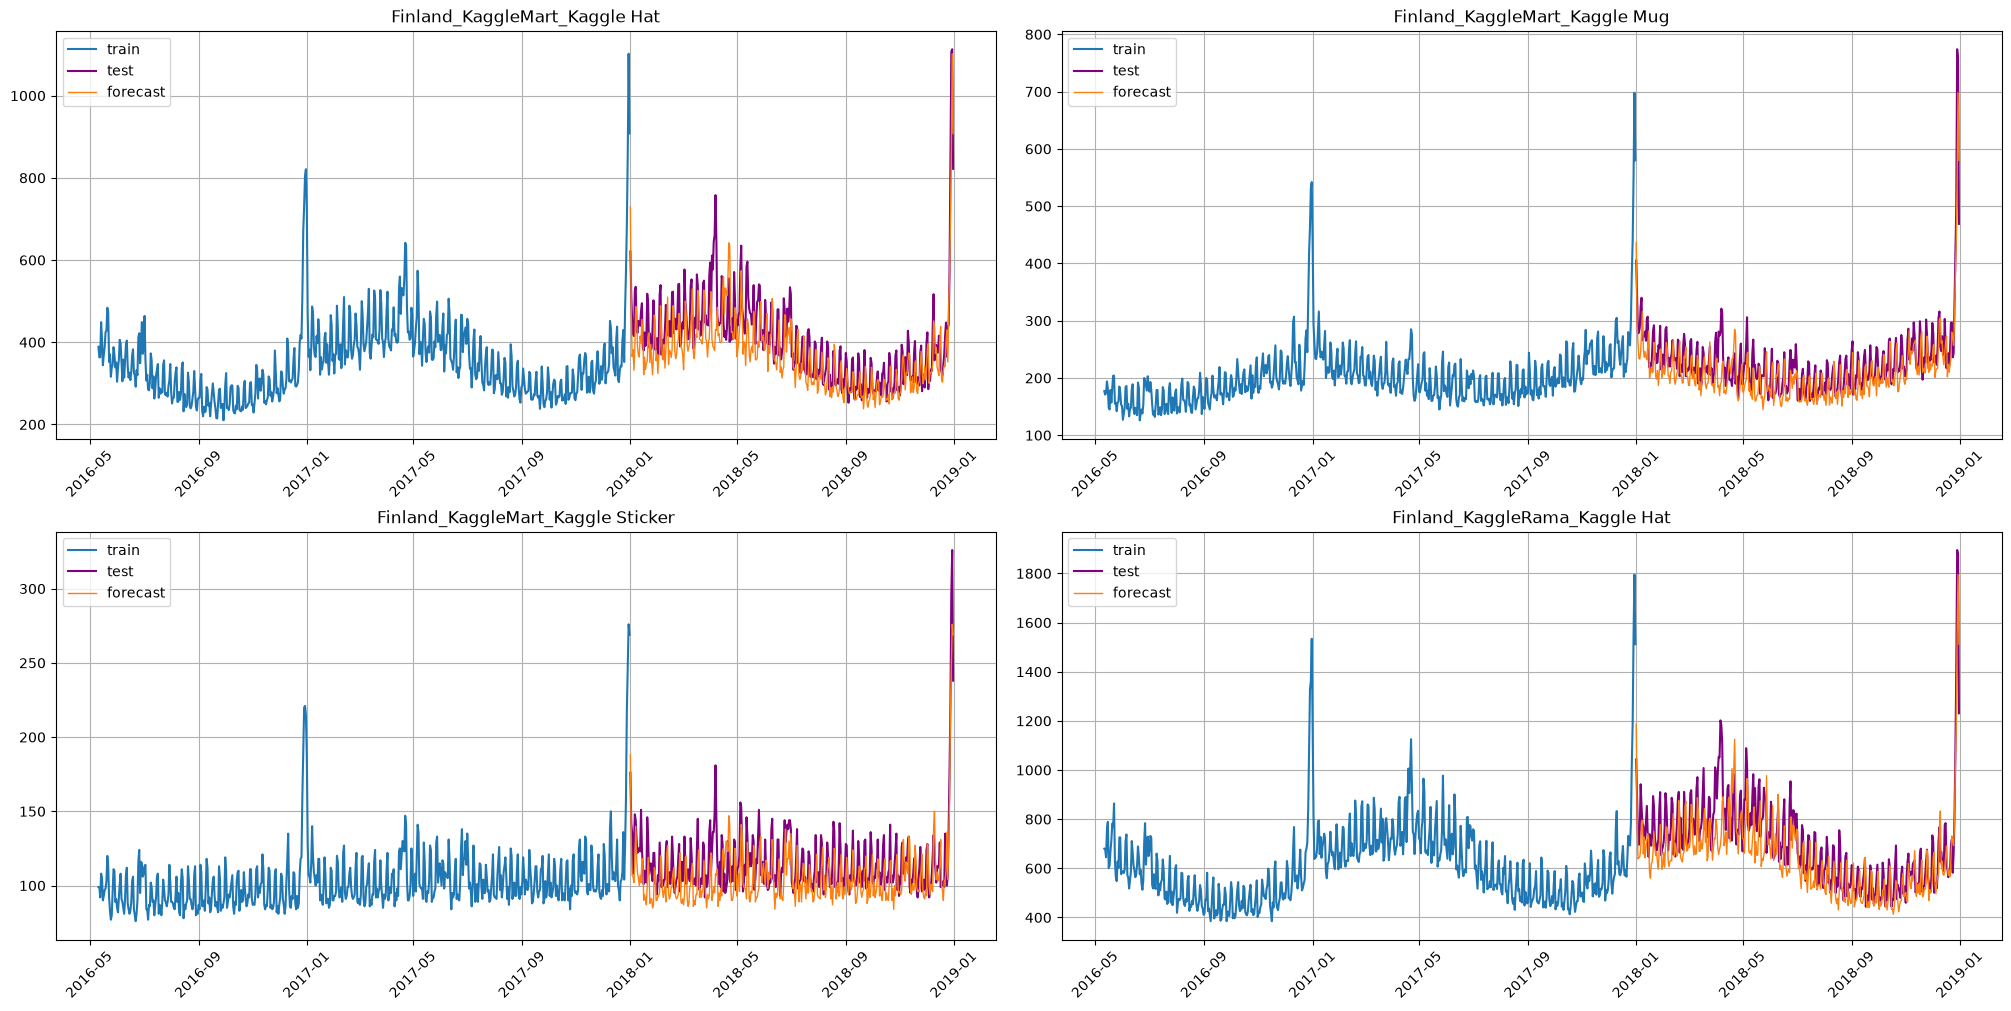

In [24]:
plot_forecast(
    forecast_ts=forecast_ts,
    test_ts=test_ts,
    train_ts=train_ts,
    n_train_samples=600,
    segments=ts.segments[:4],
)

# 3. Пайплайн

Концепция пайплайна в нашей библиотеке похожа на концепцию из sklearn, по сути мы соединяем предобработку, генерацию признаков и модель в одном объекте:

> Pipeline = Model + Transforms

Этот интерфейс является **рекоммендуемым** для работы с моделями, он инкапсулируюет всю дополнительную логику, часть из которой мы проделали руками в предыдущем примере

In [26]:
from etna.pipeline import Pipeline

In [27]:
train_ts, test_ts = ts.train_test_split(
    test_start="2018-01-01",
    test_end="2019-01-01",
)

In [28]:
pipeline = Pipeline(
    model=NaiveModel(lag=HORIZON),  # Модель прогнозирования
    transforms=[],
    horizon=HORIZON,
)

In [29]:
# Все процессы по тарнсформации и генерации будущего зашиты внутрь
pipeline.fit(train_ts)
forecast_ts = pipeline.forecast()

In [31]:
metric = SMAPE()(y_true=test_ts, y_pred=forecast_ts)
print(f"Mean SMAPE of NaiveModel: {np.array(list(metric.values())).mean()}")

Mean SMAPE of NaiveModel: 13.166442283926543


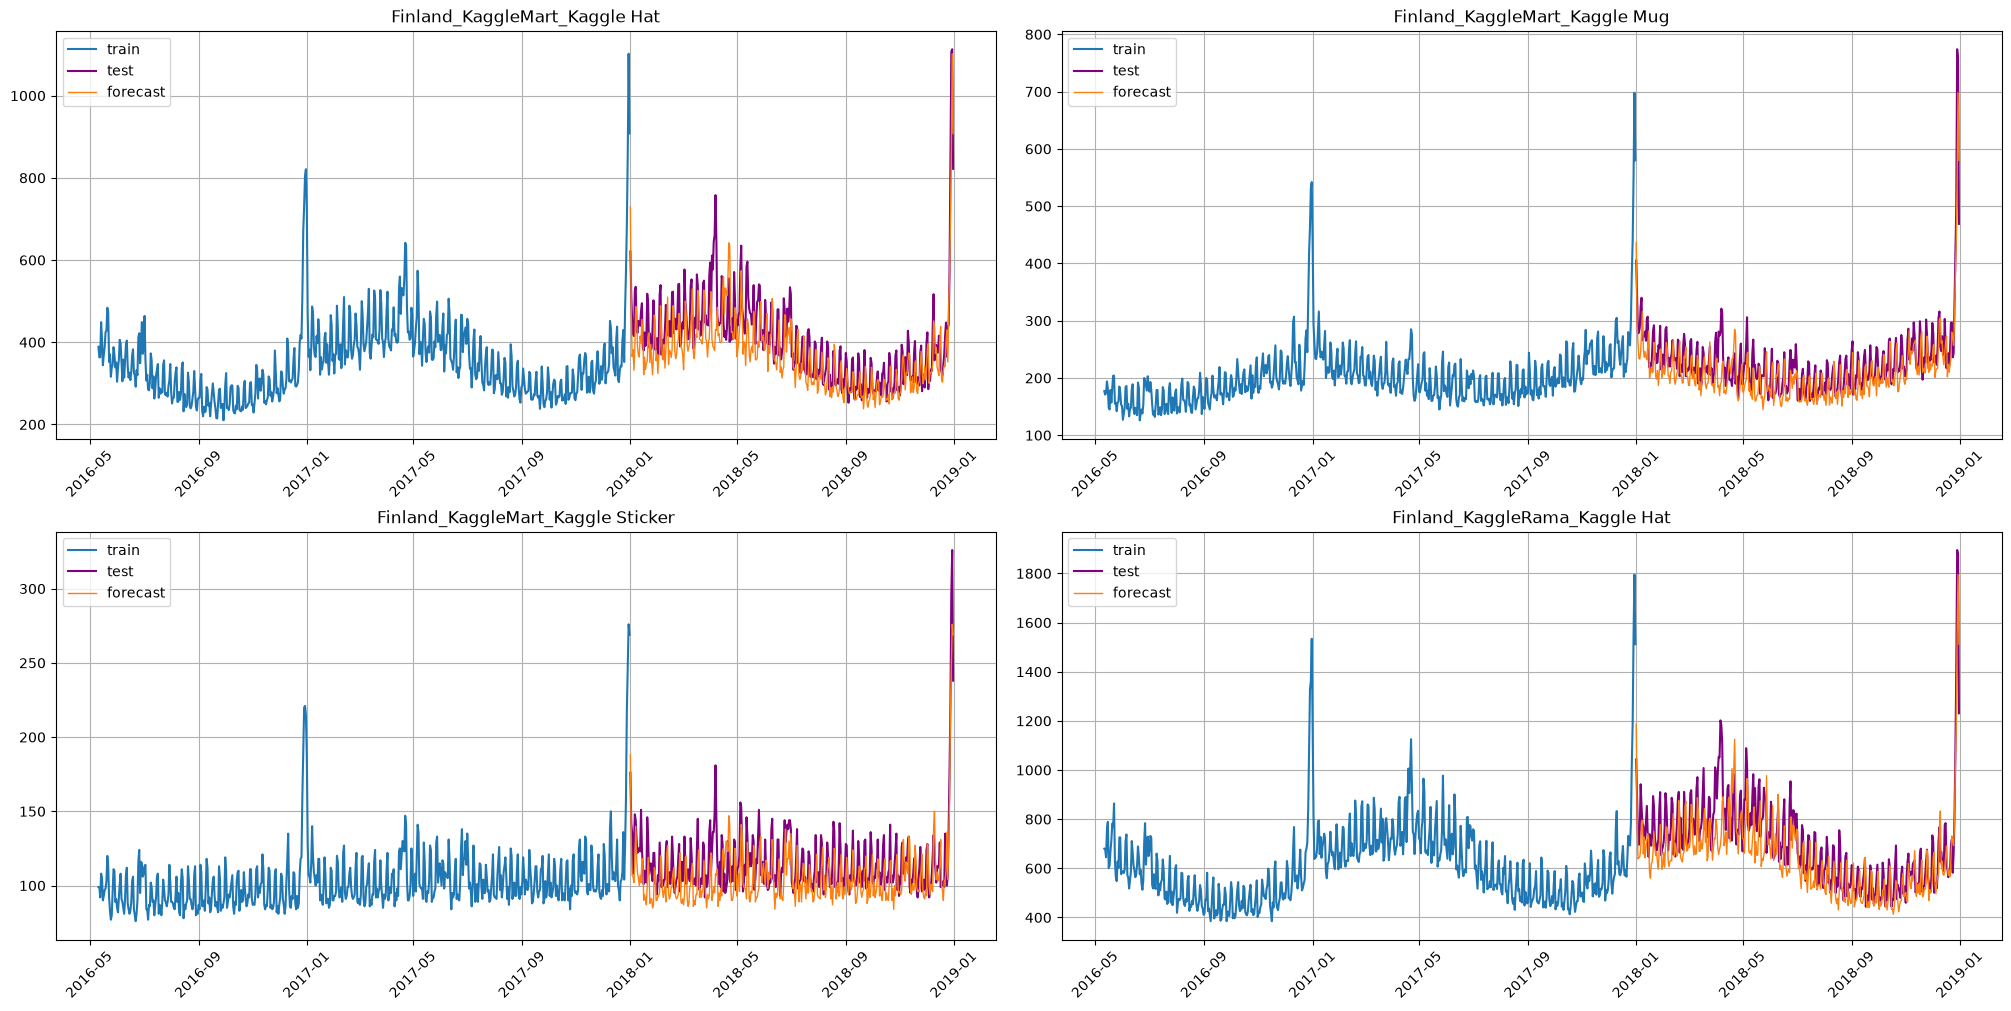

In [32]:
plot_forecast(
    forecast_ts=forecast_ts,
    test_ts=test_ts,
    train_ts=train_ts,
    n_train_samples=600,
    segments=ts.segments[:4],
)

Подробнее про механику прогнозирования можно почитать в этот туториале

https://docs.etna.ai/stable/tutorials/209-mechanics_of_forecasting.html

# 4. Кроссвалидация

Мы построили несколько вариантов пайплайна, теперь хочется научиться оценивать их качество на кросcвалидации. Ключевой особенностью временных рядов является наличие временной структуры, которую необходимо сохранять при формировании фолдов для того чтобы не допустить ликов



![](https://github.com/etna-team/etna/blob/master/examples/assets/backtest/backtest.jpg?raw=true)


На картинке изображен вариант валидации с расширяющимся окном и `stride`=horizon

Много доступных стратегий валидации, например
- Можем задавать периодичность переобучения пайплайна(`refit`)
- Можем задавать кастомное смещение между фолдами(`stride`)
- Можем кастомно формировать фолды используя вместо числа для `n_folds` специальные структуры `FoldMask`

Подробнее про кроссвалидацию в библиотеке можно почитать в нашем [ноутбуке](https://github.com/tinkoff-ai/etna/blob/master/examples/backtest.ipynb) 

## 4.1 Оценка метрик

In [33]:
from etna.metrics import MAE
from etna.metrics import SMAPE

In [34]:
backtest_result = pipeline.backtest(ts=ts, metrics=[MAE(), SMAPE()], n_folds=3)

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished


In [35]:
backtest_result.keys() # Результаты содержат метрики, исторические прогнозы, разбиение и обученные пайплайны

dict_keys(['metrics', 'forecasts', 'fold_info', 'pipelines'])

In [36]:
backtest_result["fold_info"]

,train_start_time,train_end_time,test_start_time,test_end_time,fold_number
0,2015-01-01,2016-01-01,2016-01-02,2016-12-31,0
1,2015-01-01,2016-12-31,2017-01-01,2017-12-31,1
2,2015-01-01,2017-12-31,2018-01-01,2018-12-31,2


In [37]:
backtest_result['metrics'][["MAE", "SMAPE"]].mean()

MAE      52.069964
SMAPE    12.991432
dtype: float64

## 4.2 Визуализация прогноза

In [40]:
from etna.analysis import plot_backtest

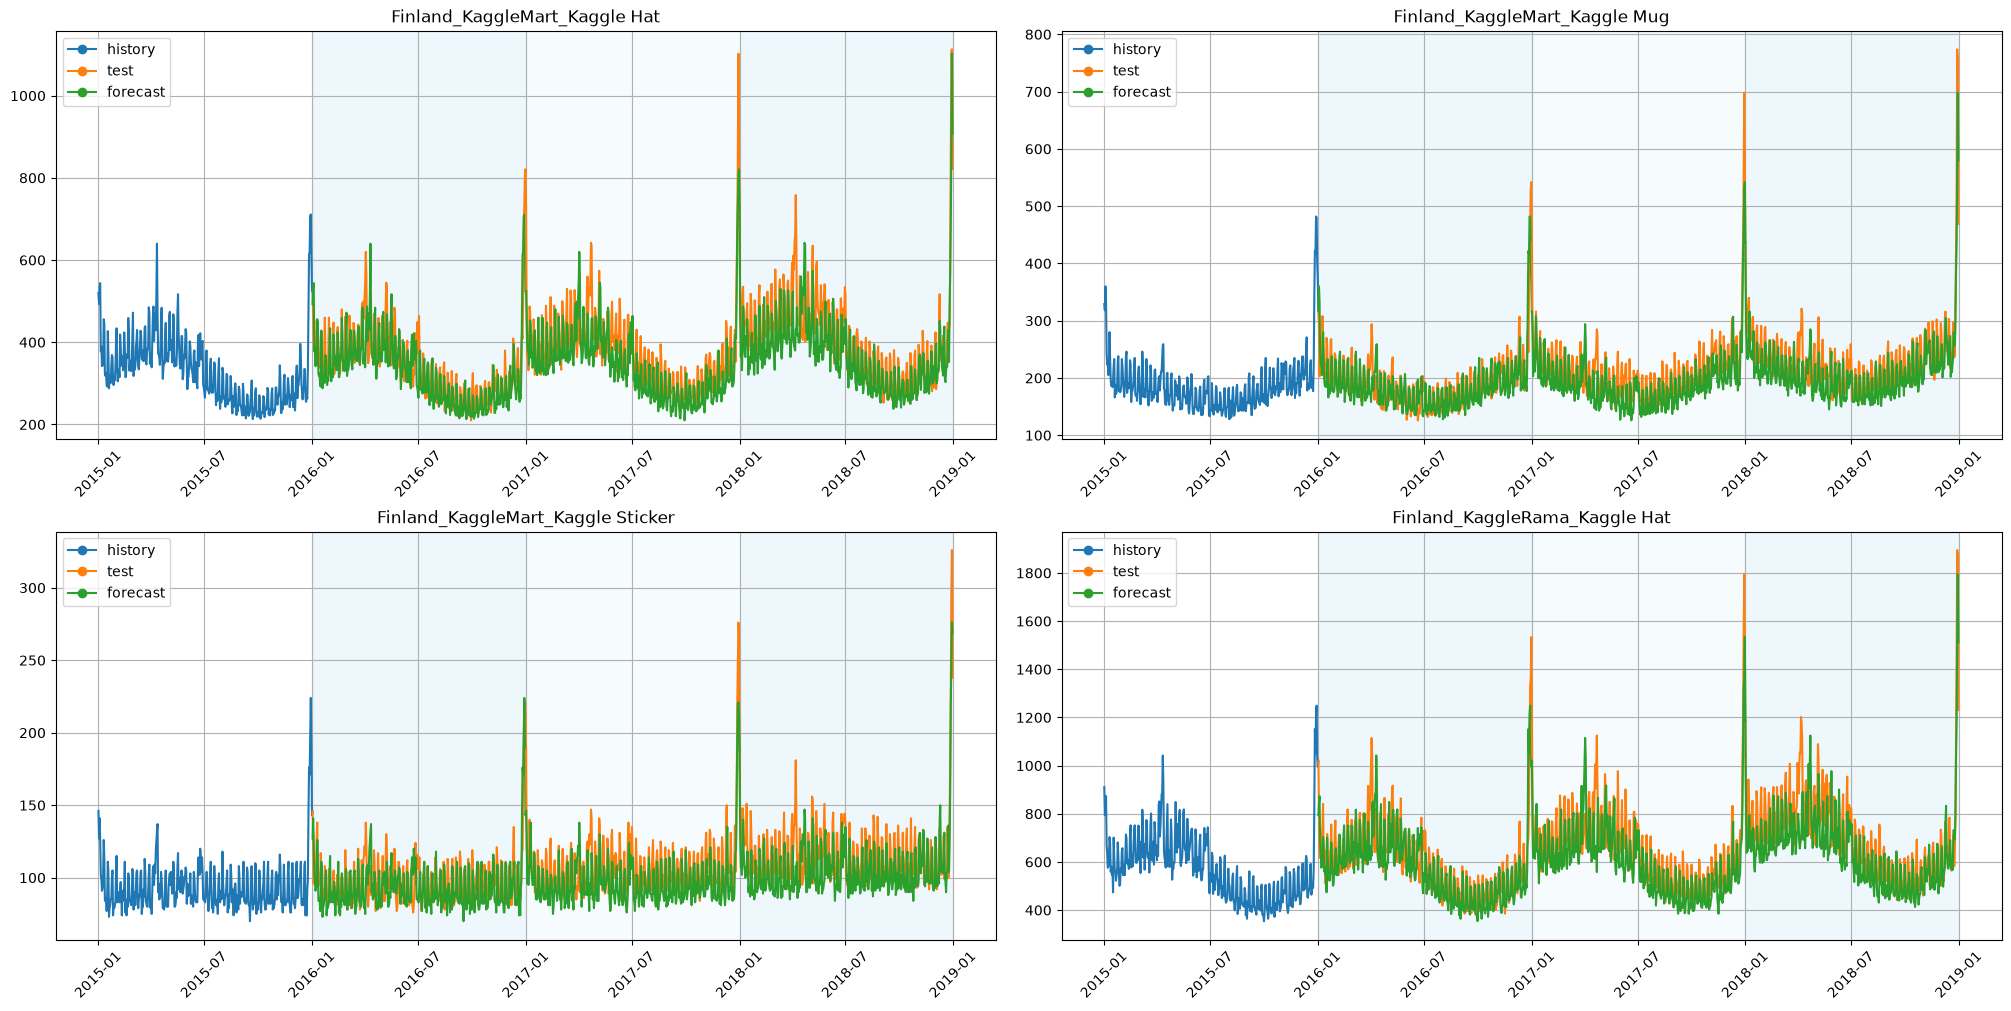

In [41]:
plot_backtest(forecast_ts_list=backtest_result['forecasts'], ts=ts, history_len=1000, segments=ts.segments[:4])